# ROMS Doppio and OOI MAB Profiler

Revised June 4, 2026 by Sage Lichtenwalner

This notebook demonstrates how to compare CTD data from the [OOI Coastal Pioneer MAB: Southern Profiler Mooring](https://oceanobservatories.org/site/cp13sopm/) with model data from ROMS Doppio.  

For this example, we will grab OOI data from Erddap, and model data from Rutgers Threadds data server.  The Thredds server provides easy access to the large model dataset, however, data requests for large areas or time periods are not possible due to the limitations of processing on the Thredds site.

We will focus on August 2025, when [Hurricane Erin](https://en.wikipedia.org/wiki/Hurricane_Erin_(2025)) passed just offshore of the MAB array.

In [23]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from erddapy import ERDDAP

## Load OOI Pioneer Data
First, we'll use erddapy to load near-surface CTD data from the Central Surface Mooring (via OOI's Data Explorer ERDDAP).

In [24]:
server = 'https://erddap.dataexplorer.oceanobservatories.org/erddap'

dataset_id = 'ooi-cp13sopm-wfp01-03-ctdpfk000'

variables = [
    'time',
    'z',
    'sea_water_temperature_profiler_depth_enabled',
    'sea_water_practical_salinity_profiler_depth_enabled',
]

constraints = {
    'time>=': '2025-08-01T00:00:00Z',
    'time<=': '2025-09-01T00:00:00Z',
}

e = ERDDAP(
    server=server,
    protocol='tabledap',
)
e.dataset_id = dataset_id
e.variables = variables
e.constraints = constraints

# Data URL
# print(e.get_download_url(response='csvp'))

df_ooi = e.to_pandas(
    response='csv',
    parse_dates=True,
    skiprows=[1],
    index_col='time',
).dropna(how='all')

df_ooi.index = pd.DatetimeIndex(df_ooi.index).tz_convert(None)

df_ooi.head()

,z,sea_water_temperature_profiler_depth_enabled,sea_water_practical_salinity_profiler_depth_enabled
time,,,
2025-08-01 00:00:00,-76.0,9.064247,33.512212
2025-08-01 00:01:00,-76.0,9.067315,33.512449
2025-08-01 00:02:00,-76.0,9.075783,33.514877
2025-08-01 00:02:00,-75.0,9.026450,33.504709
2025-08-01 00:02:00,-74.0,8.929100,33.479867


In [25]:
profile_gap = pd.Timedelta('30min')
depth_bin = 1.0

temp_col = 'sea_water_temperature_profiler_depth_enabled'
sal_col = 'sea_water_practical_salinity_profiler_depth_enabled'

def build_ooi_grid(value_col):
    work = (
        df_ooi[[value_col, 'z']]
        .dropna()
        .reset_index()
        .assign(depth=lambda d: -d['z'])
        .sort_values('time')
        .assign(
            profile_id=lambda d: d['time'].diff().gt(profile_gap).cumsum(),
            profile_time=lambda d: d.groupby('profile_id')['time'].transform('min').dt.tz_localize(None),
            depth_bin_center=lambda d: np.round(d['depth'] / depth_bin) * depth_bin,
        )
        .groupby(['profile_time', 'depth_bin_center'], as_index=False)[value_col]
        .mean()
    )
    return work.pivot(index='depth_bin_center', columns='profile_time', values=value_col).sort_index().sort_index(axis=1)

ooi_temp_grid = build_ooi_grid(temp_col)
ooi_sal_grid = build_ooi_grid(sal_col)

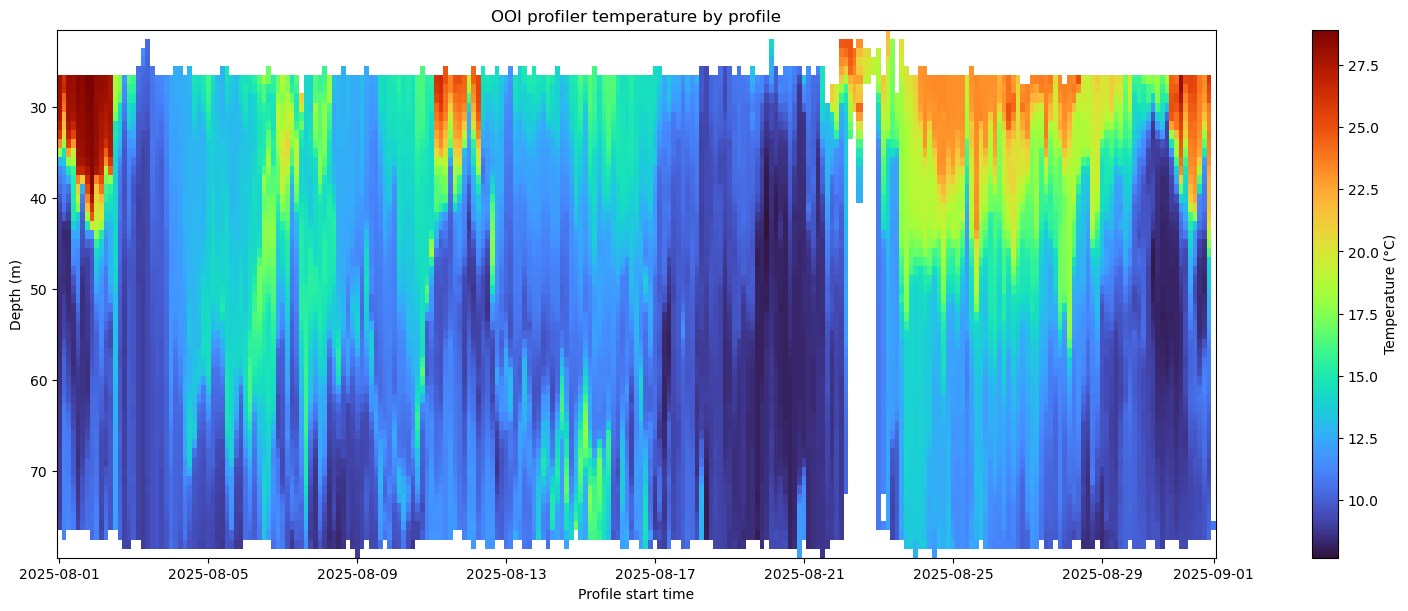

In [26]:
fig, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)
pcm = ax.pcolormesh(
    ooi_temp_grid.columns,
    ooi_temp_grid.index,
    ooi_temp_grid.values,
    shading='auto',
    cmap='turbo',
)
# ax.set_ylim(0.0, float(ooi_temp_grid.index.max()))
ax.invert_yaxis()
ax.set_ylabel('Depth (m)')
ax.set_xlabel('Profile start time')
ax.set_title('OOI profiler temperature by profile')
fig.colorbar(pcm, ax=ax, label='Temperature (°C)')
plt.show()

## Load ROMS Profile Timeseries Data

In [27]:
doppio_url = 'https://tds.marine.rutgers.edu/thredds/dodsC/roms/doppio/2017_da/his/History_Best'
ds = xr.open_dataset(doppio_url)
ds

<xarray.Dataset> Size: 7TB
Dimensions:         (time: 75300, time1: 75300, time2: 480, time3: 75300,
                     tracer: 2, boundary: 4, s_rho: 40, s_w: 41, eta_rho: 106,
                     xi_rho: 242, eta_u: 106, xi_u: 241, eta_v: 105, xi_v: 242,
                     eta_psi: 105, xi_psi: 241, ocean_time: 24)
Coordinates: (12/18)
  * time            (time) datetime64[ns] 602kB 2017-11-02T01:00:00 ... 2026-...
    time_run        (time) datetime64[ns] 602kB ...
  * time1           (time1) datetime64[ns] 602kB 2017-11-02T01:00:00 ... 2026...
    time1_run       (time1) datetime64[ns] 602kB ...
  * time2           (time2) datetime64[ns] 4kB 2023-06-30T01:00:00 ... 2024-1...
  * time3           (time3) datetime64[ns] 602kB 2017-11-02T01:00:00 ... 2026...
    ...              ...
    lat_u           (eta_u, xi_u) float64 204kB ...
    lon_v           (eta_v, xi_v) float64 203kB ...
    lat_v           (eta_v, xi_v) float64 203kB ...
    lon_psi         (eta_psi, xi_psi) float64 202kB ...
    lat_psi         (eta_psi, xi_psi) float64 202kB ...
  * ocean_time      (ocean_time) datetime64[ns] 192B 2026-06-03T01:00:00 ... ...
Dimensions without coordinates: tracer, boundary, eta_rho, xi_rho, eta_u, xi_u,
                                eta_v, xi_v, eta_psi, xi_psi
Data variables: (12/123)
    time_offset     (time) datetime64[ns] 602kB ...
    time1_offset    (time1) datetime64[ns] 602kB ...
    time2_run       (time2) datetime64[ns] 4kB ...
    time2_offset    (time2) datetime64[ns] 4kB ...
    time3_offset    (time3) datetime64[ns] 602kB ...
    ntimes          int32 4B ...
    ...              ...
    sustr           (time1, eta_u, xi_u) float64 15GB ...
    svstr           (time1, eta_v, xi_v) float64 15GB ...
    v_northward_1m  (time, eta_rho, xi_rho) float64 15GB ...
    u_eastward_1m   (time, eta_rho, xi_rho) float64 15GB ...
    Vwind           (time, eta_rho, xi_rho) float64 15GB ...
    Uwind           (time, eta_rho, xi_rho) float64 15GB ...
Attributes: (12/41)
    file:                            doppio_his_7456_0003.nc
    format:                          netCDF-4/HDF5 file
    Conventions:                     CF-1.4, SGRID-0.3
    type:                            ROMS/TOMS history file
    title:                           ROMS doppio Real-Time Operational PSAS F...
    var_info:                        ../Data/varinfo1040t_daily.dat
    ...                              ...
    cdm_data_type:                   GRID
    featureType:                     GRID
    location:                        Proto fmrc:doppio_2017_da_his
    summary:                         doppio
    DODS_EXTRA.Unlimited_Dimension:  ocean_time
    EXTRA_DIMENSION.N:               40

In [28]:
print('\nDataset summary')
print(f'  Size:    {ds.nbytes/1e12:,.3f} TB')

print('Temperature summary')
temp_var = ds['temp']
print(f'  dims:        {temp_var.dims}')
print(f'  shape:       {temp_var.shape}')
print(f'  dtype:       {temp_var.dtype}')
print(f'  n_values:    {temp_var.size:,}')
print(f'  size:        {temp_var.nbytes/1e9:,.1f} GB')
print(f'  attrs:       {temp_var.attrs}')



Dataset summary
  Size:    6.512 TB
Temperature summary
  dims:        ('time', 's_rho', 'eta_rho', 'xi_rho')
  shape:       (75300, 40, 106, 242)
  dtype:       float64
  n_values:    77,263,824,000
  size:        618.1 GB
  attrs:       {'units': 'Celsius', 'long_name': 'potential temperature', 'time': 'ocean_time', 'grid': 'grid', 'location': 'face', 'field': 'temperature, scalar, series', '_ChunkSizes': array([  1,  20,  53, 121], dtype=int32), 'standard_name': 'sea_water_potential_temperature'}


This is a lot of data, and if you try to load a full variable, it will take a VERY long time, assuming it even works at all.  Thus, you need to be very careful when accessing data to make sure you pre-select the time, lat/long and depth bins you need.  And even then, you may need to access the data in smaller chunks - and then cache the data you download locally so you do not need to access them again and again.

## Finding the closest grid point to the Mooring
In order to extract the model data, we need to know the mooring location.

In [29]:
ooi_lat = 35 + 43.3062/60
ooi_lon = -74 - 51.2670/60

print(f'Mooring location: {ooi_lat:.4f}, {ooi_lon:.4f}')

Mooring location: 35.7218, -74.8544


In [30]:
# Step 1: Find nearest ROMS grid point to OOI mooring.
lon2d = ds['lon_rho']
lat2d = ds['lat_rho']
dist2 = (lon2d - ooi_lon) ** 2 + (lat2d - ooi_lat) ** 2
eta_idx, xi_idx = np.unravel_index(np.nanargmin(dist2.values), dist2.shape)

grid_lat = float(lat2d.isel(eta_rho=eta_idx, xi_rho=xi_idx).values) 
grid_lon = float(lon2d.isel(eta_rho=eta_idx, xi_rho=xi_idx).values) 

print(f'Nearest grid index: eta={eta_idx}, xi={xi_idx}')
print(f'Nearest grid lat/lon: {grid_lat:.4f}, {grid_lon:.4f}')

# Step 2: Get bathymetric depth (h) at the nearest ROMS rho-grid point.
point_depth_m = float(ds['h'].isel(eta_rho=eta_idx, xi_rho=xi_idx).values)
point_mask = int(ds['mask_rho'].isel(eta_rho=eta_idx, xi_rho=xi_idx).values)

print(f'Bathymetric depth at nearest grid point: {point_depth_m:.2f} m')
print(f'Land/sea mask at point (1=ocean, 0=land): {point_mask}')

Nearest grid index: eta=40, xi=39
Nearest grid lat/lon: 35.7549, -74.8498
Bathymetric depth at nearest grid point: 336.64 m
Land/sea mask at point (1=ocean, 0=land): 1


In [31]:
# Calculate distiance between OOI mooring and nearest grid point
from geopy.distance import geodesic     
ooi_coords = (ooi_lat, ooi_lon)
grid_coords = (grid_lat, grid_lon)
distance_km = geodesic(ooi_coords, grid_coords).kilometers
print(f'Distance between OOI mooring and nearest grid point: {distance_km:.2f} km')

Distance between OOI mooring and nearest grid point: 3.70 km


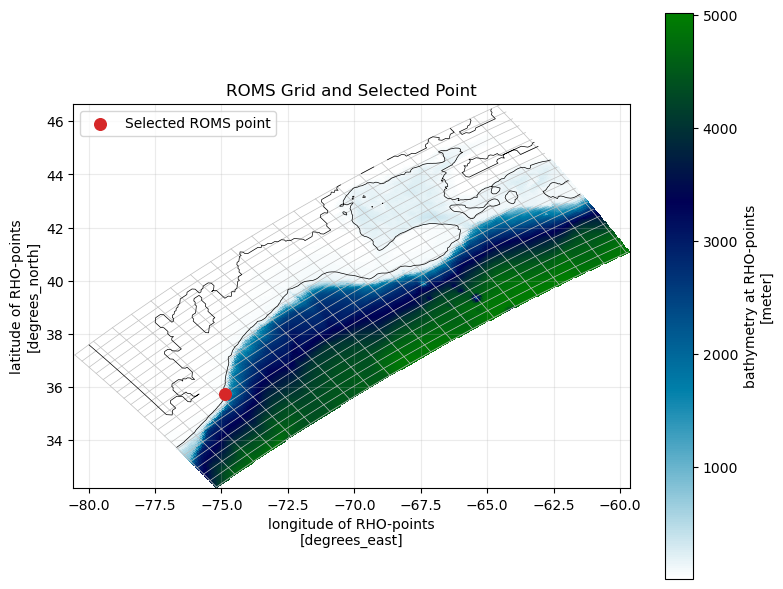

In [32]:
# Simple map: ROMS grid + selected nearest point.
fig, ax = plt.subplots(figsize=(8, 6))

# Subsample grid lines to keep plotting light and readable.
step_eta = max(1, lat2d.shape[0] // 20)
step_xi = max(1, lat2d.shape[1] // 20)

for eta in range(0, lat2d.shape[0], step_eta):
    ax.plot(lon2d.isel(eta_rho=eta), lat2d.isel(eta_rho=eta), color='0.75', lw=0.5)
for xi in range(0, lon2d.shape[1], step_xi):
    ax.plot(lon2d.isel(xi_rho=xi), lat2d.isel(xi_rho=xi), color='0.75', lw=0.5)

ax.scatter(grid_lon, grid_lat, s=70, c='tab:red', marker='o', label='Selected ROMS point', zorder=3)

ds.h.plot.pcolormesh(x = 'lon_rho', y = 'lat_rho', cmap='ocean_r')
ds.h.plot.contour(x = 'lon_rho', y = 'lat_rho', colors='k', levels=[5, 100], linewidths=0.5)

# ax.set_xlabel('Longitude')
# ax.set_ylabel('Latitude')
ax.set_title('ROMS Grid and Selected Point')
ax.legend(loc='best')
ax.grid(True, alpha=0.25)
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

In [33]:
ds_profile_temp = ds['temp'].sel(time=slice('2025-08-01', '2025-09-01'), eta_rho=eta_idx, xi_rho=xi_idx).load()
ds_profile_sal = ds['salt'].sel(time=slice('2025-08-01', '2025-09-01'), eta_rho=eta_idx, xi_rho=xi_idx).load()

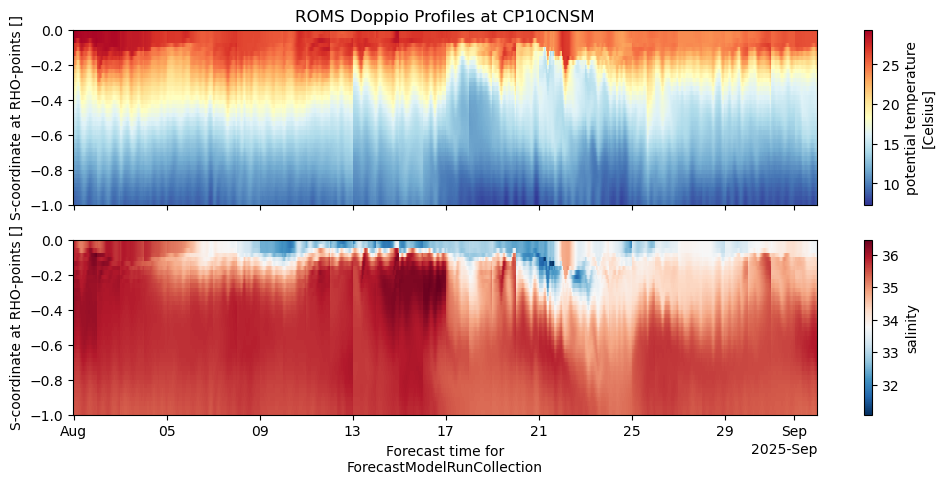

In [34]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ds_profile_temp.plot(y='s_rho', yincrease=False, ax=axes[0], cmap='RdYlBu_r', vmin=ds_profile_temp.min(), vmax=ds_profile_temp.max())
ds_profile_sal.plot(y='s_rho', yincrease=False, ax=axes[1], cmap='RdBu_r', vmin=ds_profile_sal.min(), vmax=ds_profile_sal.max())

axes[0].invert_yaxis()
axes[1].invert_yaxis()

axes[0].set_title('ROMS Doppio Profiles at CP10CNSM')
axes[0].set_xlabel('')
axes[1].set_title('');

In [35]:
# Same point and time range as ds_profile_temp
zeta_pt = ds["zeta"].sel(
    time=slice('2025-08-01', '2025-09-01'),
    eta_rho=eta_idx,
    xi_rho=xi_idx,
)

h_pt = ds["h"].isel(eta_rho=eta_idx, xi_rho=xi_idx)
hc = ds["hc"]
s_rho = ds["s_rho"]
Cs_r = ds["Cs_r"]
Vtransform = int(ds["Vtransform"])

if Vtransform == 1:
    z0 = hc * (s_rho - Cs_r) + h_pt * Cs_r
    z_rho = z0 + zeta_pt * (1 + z0 / h_pt)
elif Vtransform == 2:
    z0 = (hc * s_rho + h_pt * Cs_r) / (hc + h_pt)
    z_rho = zeta_pt + (zeta_pt + h_pt) * z0
else:
    raise ValueError(f"Unsupported Vtransform: {Vtransform}")

# Store depth as positive meters downward for direct comparison with OOI.
ds_profile_temp = ds_profile_temp.assign_coords(depth=(-z_rho).transpose("time", "s_rho"))
ds_profile_sal = ds_profile_sal.assign_coords(depth=(-z_rho).transpose("time", "s_rho"))

Text(0, 0.5, 'Depth (m)')

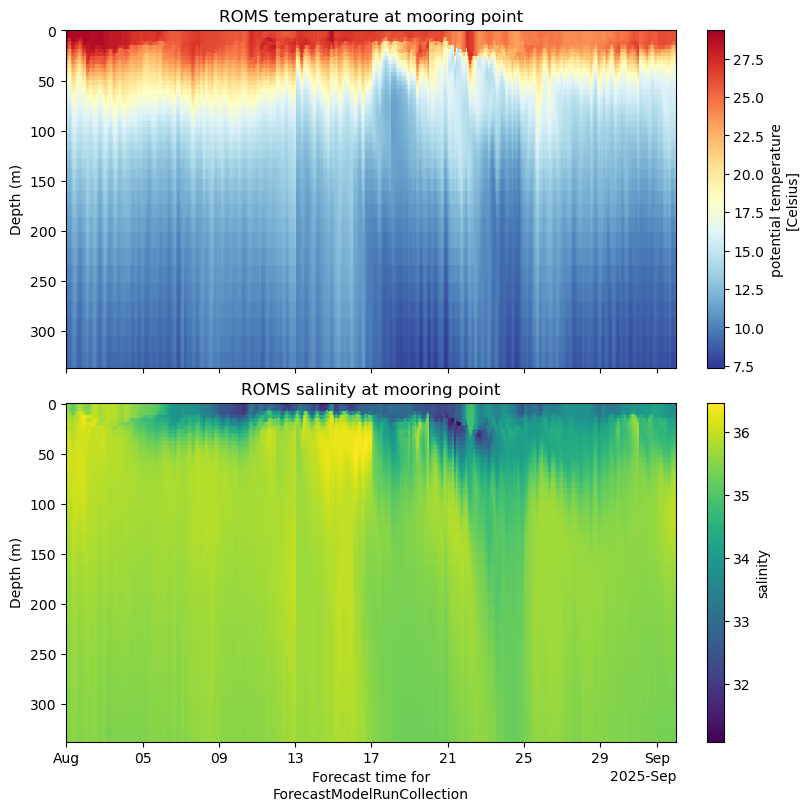

In [45]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True, sharey=True, constrained_layout=True)

ds_profile_temp.plot(
    x="time",
    y="depth",
    yincrease=False,
    ax=axes[0],
    cmap="RdYlBu_r",
)

ds_profile_sal.plot(
    x="time",
    y="depth",
    yincrease=False,
    ax=axes[1],
    cmap="viridis",
)

axes[0].set_title("ROMS temperature at mooring point")
axes[1].set_title("ROMS salinity at mooring point")
axes[0].set_xlabel("")
axes[0].set_ylabel("Depth (m)")
axes[1].set_ylabel("Depth (m)")

# axes[0].set_ylim([80,0])  # Focus on upper 80 m to better compare with OOI profiler data

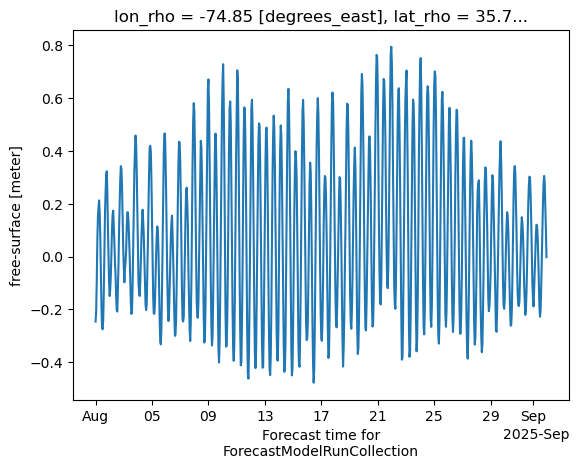

In [37]:
zeta_pt.plot()

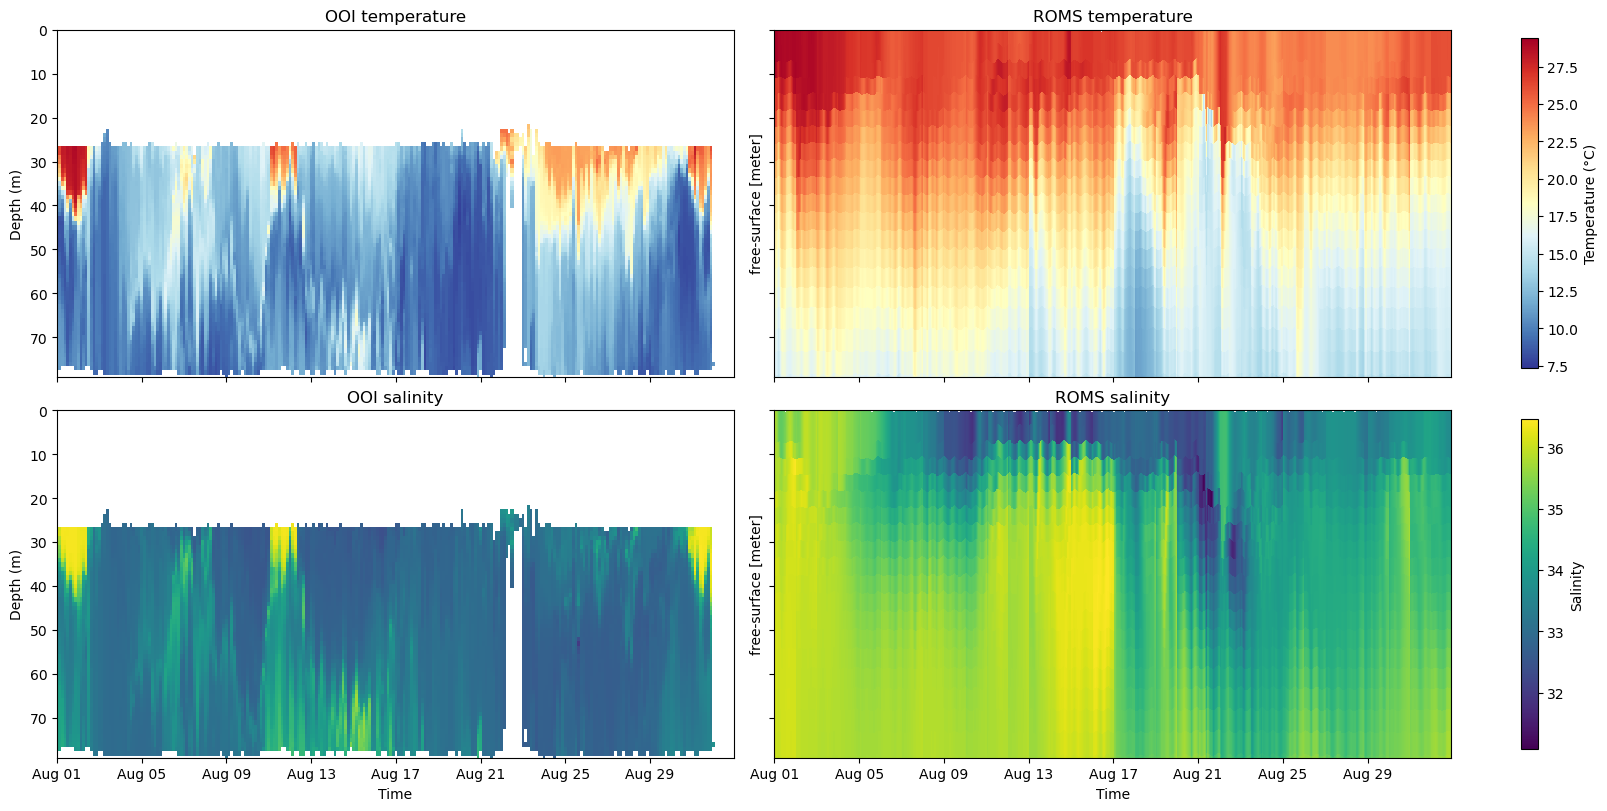

In [38]:
import matplotlib.dates as mdates

temp_vmin = min(np.nanmin(ooi_temp_grid.to_numpy()), float(ds_profile_temp.min(skipna=True)))
temp_vmax = max(np.nanmax(ooi_temp_grid.to_numpy()), float(ds_profile_temp.max(skipna=True)))
sal_vmin = min(np.nanmin(ooi_sal_grid.to_numpy()), float(ds_profile_sal.min(skipna=True)))
sal_vmax = max(np.nanmax(ooi_sal_grid.to_numpy()), float(ds_profile_sal.max(skipna=True)))

# Keep the comparison focused on the OOI sampling range, but include the surface.
plot_depth_top = 0.0
plot_depth_bottom = max(
    float(ooi_temp_grid.index.max()),
    float(ooi_sal_grid.index.max()),
)

ooi_time_start = pd.to_datetime(min(ooi_temp_grid.columns.min(), ooi_sal_grid.columns.min())).to_datetime64()
ooi_time_end = pd.to_datetime(max(ooi_temp_grid.columns.max(), ooi_sal_grid.columns.max())).to_datetime64()
roms_time_start = pd.to_datetime(min(ds_profile_temp.time.min().values, ds_profile_sal.time.min().values)).to_datetime64()
roms_time_end = pd.to_datetime(max(ds_profile_temp.time.max().values, ds_profile_sal.time.max().values)).to_datetime64()
plot_time_start = min(ooi_time_start, roms_time_start)
plot_time_end = max(ooi_time_end, roms_time_end)

fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True, sharey=True, constrained_layout=True)

temp_ooi = axes[0, 0].pcolormesh(
    ooi_temp_grid.columns,
    ooi_temp_grid.index,
    ooi_temp_grid.values,
    shading='auto',
    cmap='RdYlBu_r',
    vmin=temp_vmin,
    vmax=temp_vmax,
)
ds_profile_temp.plot(
    x='time',
    y='depth',
    ax=axes[0, 1],
    add_colorbar=False,
    cmap='RdYlBu_r',
    vmin=temp_vmin,
    vmax=temp_vmax,
)
sal_ooi = axes[1, 0].pcolormesh(
    ooi_sal_grid.columns,
    ooi_sal_grid.index,
    ooi_sal_grid.values,
    shading='auto',
    cmap='viridis',
    vmin=sal_vmin,
    vmax=sal_vmax,
)
ds_profile_sal.plot(
    x='time',
    y='depth',
    ax=axes[1, 1],
    add_colorbar=False,
    cmap='viridis',
    vmin=sal_vmin,
    vmax=sal_vmax,
)

for ax in axes.flat:
    ax.set_ylim(plot_depth_top, plot_depth_bottom)
    ax.invert_yaxis()
    ax.set_xlim(pd.Timestamp(plot_time_start), pd.Timestamp(plot_time_end))

for ax in axes[1, :]:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

axes[0, 0].set_title('OOI temperature')
axes[0, 1].set_title('ROMS temperature')
axes[1, 0].set_title('OOI salinity')
axes[1, 1].set_title('ROMS salinity')
axes[0, 0].set_ylabel('Depth (m)')
axes[1, 0].set_ylabel('Depth (m)')
axes[1, 0].set_xlabel('Time')
axes[1, 1].set_xlabel('Time')
axes[0, 0].set_xlabel('')
axes[0, 1].set_xlabel('')

fig.colorbar(temp_ooi, ax=axes[0, :], label='Temperature (°C)', shrink=0.95)
fig.colorbar(sal_ooi, ax=axes[1, :], label='Salinity', shrink=0.95)
plt.show()